# Working in Google Colab

This notebook is published from GitHub. Before editing it:

1. Sign in to Google, if prompted.
2. Click **Copy to Drive** at the top of Colab. If that button is not visible, choose **File → Save a copy in Drive**.
3. Close the original tab and work in the new Drive copy.

To start over, reopen the original course link and make a fresh copy.

# Project 1 : A DIY Neuron Model -  Part 2



### Previously:
In the first part of the  project we synthetized the **Hodgkin Huxley model of action potential**, piece by piece, by adding individual currents. Now it is time to get empirical and experiment with parameters that represent experimental conditions, to gain intuition about what causes spiking.

In other words, we will be running some **protocols** for in-silico **experiments**, and reasoning about what we observe.


# Initialization Code

- In the code cell below we install the simulator [Brian2](https://brian2.readthedocs.io/) and import relevant python.modules.
- It installs and imports Brian2, the simulator we will be using.
- **Note that you have to run this every time that colab 'disconnects' from the kernel.**
- Documentation of brian2 can be found [here](https://brian2.readthedocs.io/en/stable/user/index.html)

In [1]:
# install brian2

# import necesary packages
from IPython.display import display
from brian2 import * # our simulator of choice
import brian2.numpy_ as np # the numpy that comes bundled with it
from ipywidgets import interact, interactive # for some neat interactions
from IPython.display import display
import ipywidgets as widgets
import matplotlib.pyplot as plt # for neat plots
import time # for time basis conversions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 6.3 MB/s eta 0:00:00


# The Anatomy of a Spike

## Coding Exercise: Reproduce Izhikevich's Nice Figure

To warm up we will want to reproduce the figure below from Izhikevich (2007).

First study the entire figure, panel by panel. Do you know what is plotted?

Then note: there are two current injections at 2 and at 10ms. We observe a spike upon the second injection and not the first. We would like to plot all of the relevant variables to get a qualitative understanding of the interaction between the different conductances, currents and activation gates.

- you should guess on the parameters for the current injection based on the graphs below.
- parameters and equations are copied from the previous project for your
convenience, but you should create your Brian model.
- to record the variables use Brian's state monitor.
- use plt.subplot just like in matlab to produce stacked subplots.
- for axis labels, simply use the physical units.
- in the plot with multiple traces use colors and a legend.

[![HH Action Potential](https://i.postimg.cc/kgzyfgzN/image.png)](https://postimg.cc/7517Lwxb)

> Nota Bene: In the graph below the $V_{rest}=0mV$. This is because in the original version of the model, Hodgkin and Huxley decided to shift the potential by +65mV "to make things easier". Over the years this led to much confusion! We want to reproduce the same figure as below, but we want the 'correct' resting membrane potential of -65mV.


#### Define Parameters and Equations

In [7]:
### The Hodgkin Huxley Equations and Parameters

start_scope()
##################### Parameters:
# Reversal Potentials
E_leak = -54.4 * mV
E_Na   =  55.   * mV
E_K    = -77.   * mV

# Conductances
## attention to UNITS! For instance uS << mS
g_leak =   300. * uS / cm ** 2
gbar_Na   = 120. * mS / cm ** 2 # ('bar' means maximal conductance)
gbar_K    =  36. * mS / cm ** 2

# Membrane Capacitance
Cm = 1. * uF / cm ** 2

##################### Equations:
eqs_V ='''
dv/dt = (I -I_leak - I_Na - I_K )/Cm : volt
'''

# note: below we broke down the equations in conductance and current equations
# we need this to have access to the conductances via Brian's state monitor function

eqs_cond = '''
g_Na = gbar_Na*(m**3)*h           : siemens / meter ** 2
g_K  = gbar_K*(n**4)              : siemens / meter ** 2
'''

eqs_I = '''
I_leak = g_leak * (v - E_leak)   : amp / meter ** 2
I_Na =   g_Na   * (v - E_Na)     : amp / meter ** 2
I_K =    g_K    * (v - E_K)      : amp / meter ** 2
I                                : amp / meter ** 2
'''

# here you add the equations defining the potassium activation gates
eqs_activation= '''
n_inf =  1/(1+exp((-53*mV -v)/(15*mV))) : 1
m_inf =  1/(1+exp((-40*mV -v)/(9*mV)))  : 1
h_inf =  1/(1+exp((-62*mV -v)/(-7*mV))) : 1
taun  =  1.1*ms + 4.7*exp(-(-79*mV-v)**2/(50*mV)**2) *ms : second
taum  =  .04*ms + .46*exp(-(-38*mV-v)**2/(30*mV)**2) *ms : second
tauh  =  1.2*ms + 7.4*exp(-(-67*mV-v)**2/(20*mV)**2) *ms : second
dm/dt = (m_inf - m)/taum : 1
dh/dt = (h_inf - h)/tauh : 1
dn/dt = (n_inf - n)/taun : 1
'''

# notice that we simply "concatenate" the strings with all equations
# ( with the operator+=).
eqs = eqs_V
eqs += eqs_cond
eqs += eqs_I
eqs += eqs_activation

In [8]:
# SETUP

# 1. Create the Model

G = NeuronGroup(1,eqs, 'euler', dt=0.025*ms)

# 2. Create a state monitor

M = StateMonitor(G, ['v','m','h','n', 'I', 'g_K', 'g_Na', 'I_leak', 'I_Na', 'I_K'], record=0)

store('setup') # this saves the model for later use

In [9]:
# 3. Set an Initial Conditions (Initialize state variables)
G.m = 0.06452912
G.h = 0.57323377
G.n = 0.32350875
G.v = -64.06540041*mV

# 4. Run the Model
# 4.1 resting
G.I = 0 * uA * cm ** -2
run(2*ms)

# 4.2 Hyperpolarizing injection
G.I = 5. * uA * cm ** -2
run( .5 *ms)

# 4.3 Relaxing back to rest
G.I = 0 * uA * cm ** -2
run(7.5*ms)

# 4.4 Hyperpolarizing injection
G.I = 30. * uA * cm ** -2
run( .5 *ms)

# 4.5 Relaxing back to rest
G.I = 0 * uA * cm ** -2
run(9.5*ms)

Text(0, 0.5, 'current (mA/cm^2)')

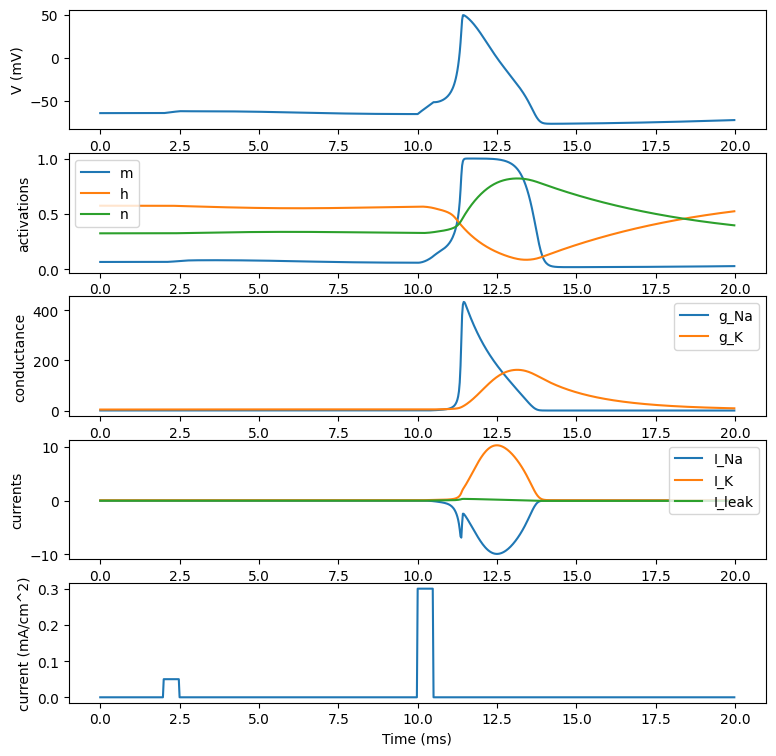

In [12]:
# 4. Plot recorded variables

# plot it
plt.figure(1, figsize=[9,9], dpi=100)

plt.subplot(5,1,1)
plt.plot(M.t/ms, M.v[0]/mV)
plt.ylabel('V (mV)')

plt.subplot(5,1,2)
plt.plot(M.t/ms, M.m[0], label ='m')
plt.plot(M.t/ms, M.h[0], label ='h')
plt.plot(M.t/ms, M.n[0], label ='n')
plt.ylabel('activations')
plt.legend(['m','h','n']);

plt.subplot(5,1,3)
plt.plot(M.t/ms, M.g_Na[0])
plt.plot(M.t/ms, M.g_K[0])
plt.ylabel('conductance')
plt.legend(['g_Na', 'g_K']);

plt.subplot(5,1,4)
plt.plot(M.t/ms, M.I_Na[0])
plt.plot(M.t/ms, M.I_K[0])
plt.plot(M.t/ms, M.I_leak[0])
plt.ylabel('currents')
plt.legend(['I_Na', 'I_K', 'I_leak']);

plt.subplot(5,1,5)
plt.plot(M.t/ms, M.I[0])
plt.xlabel('Time (ms)')
plt.ylabel('current (mA/cm^2)')

# What Causes A Spike?

There are **two essential components** for the **action potential generation**: a negative feedback which reduces the membrane potential when it’s high (voltage activated potassium) — i.e., hyperpolarizes the membrane when it’s depolarized, and a positive feedback which increases the membrane potential when it’s increased, based on voltage sensitive sodium channels. Spikes appear due to the imbalance/disequilibrium in conductances and their time courses.

> A spike is the product of an imbalance of the current flux

Note that the time courses and contributions to the membrane potential of the ion channels are very different: **potassium and sodium de-inactivation are slow** (slow time constant) while **sodium activates very quickly**.

In what follows we will be running experiments to build intuition about how activation variables and membrane potential interact under different stimulation conditions.

## A Spiking Analogy
---

 **Here's an analogy:**. In a house, the number of open windows and air conditioners has to do with the difference between outside and inside temperature, and the temperature preference of people inside the house, **Na**dia, **K**onrad and **Cl**aire.

- **Na**dia likes it hot and when the temperature picks up she starts to dance, increasing the temperature in the room.

- The hotter **Na**dia gets, the more windows Konrad opens, but that takes time (tau), so the temperature increases faster than Konrad manages to open windows.

- But then **Na**dia overheats (spikes) and has to rest for a while (inactivated state). **K**onrad gets activated when he sees that Nadia is dancing, so when she starts to franctically dance, he opens the windows.

- Because **Cl**aire likes it cold, she always has an air conditioning on, so temperature is always going lower (heat is constantly leaking at a steady rate).


---

# Experiments, interpretation and parameter exploration

Using the standard HH equations (pre-defined in the code for your convenience), conduct the experiments suggested. **For every experiment, explain what you see in terms of activation variables, conductances and the resting membrane potential**.

If you have doubts or remarks, they will be very welcome in our forums!


## Current Injection Protocols


#### Protocol 1. Produce a 'transient' until relaxation for 300s. Start the model with the following initial values:
- v = -65 mV
- m = 0
- h = 0
- n = 0

Plot activation variables and membrane potential.

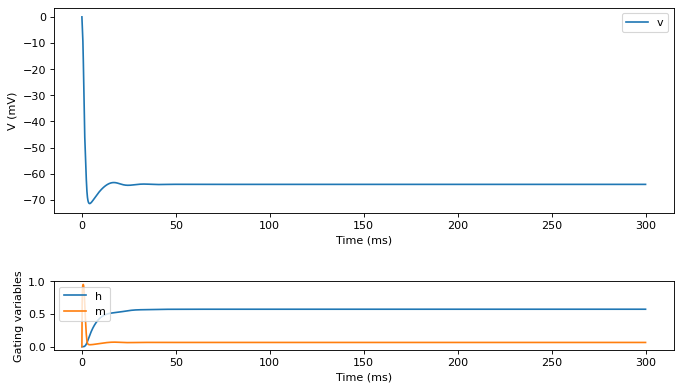

In [13]:
#Protocol 1
restore('setup')
G.v = 0*mV
G.m = 0
G.n = 0
run(300*ms)

# Plot results

# prepare a grid to plot graphs  (like function subplot in matlab)
grid = plt.GridSpec(5, 1, wspace=0.4, hspace=1)

# create figure
figure(figsize=(10, 10), dpi= 80, facecolor='w', edgecolor='k')

# in the first viewport plot membrane potential vs time
subplot(grid[:2, 0])
plot(M.t/ms, M.v[0]/mV, label='v')
xlabel('Time (ms)')
ylabel('V (mV)')
legend();


subplot(grid[2, 0])
plot(M.t/ms, M.h[0], label='h')
plot(M.t/ms, M.m[0], label='m')
xlabel('Time (ms)')
ylabel('Gating variables')
legend();

show()

#### Review and analyze:

- explain what you see!

### Protocol 2. Inject pulses of different amplitudes

  - 50ms relaxation time (no injected current)
  - 10 uA/cm^2 for 5 ms
  - relax for 50ms (no injected current, set it to zero)
  - apply -10 uA/cm^2 for 5 ms
  - relax for 100ms
  

#### Your Code Here

#### Solution

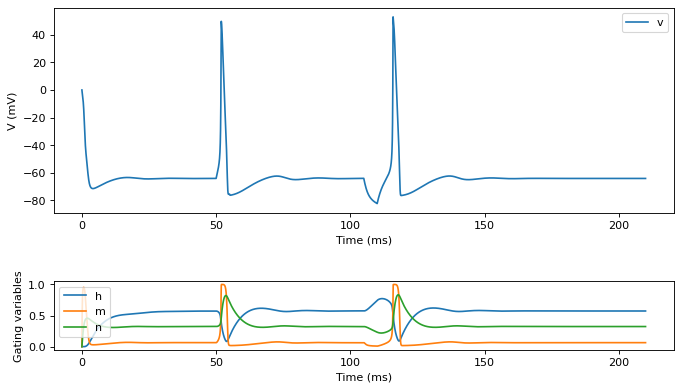

In [15]:
#Protocol 2
restore('setup')
G.v = 0*mV
G.m = 0
G.n = 0
G.h = 0
run(50*ms)

G.I = 10*uA/cm**2
run(5*ms)

G.I = 0*uA/cm**2
run(50*ms)

G.I = -10*uA/cm**2
run(5*ms)

G.I = 0* uA/cm**2
run(100*ms)

# prepare a grid to plot graphs  (like function subplot in matlab)
grid = plt.GridSpec(5, 1, wspace=0.4, hspace=1)

# create figure
figure(figsize=(10, 10), dpi= 80, facecolor='w', edgecolor='k')

# in the first viewport plot membrane potential vs time
subplot(grid[:2, 0])
plot(M.t/ms, M.v[0]/mV, label='v')
xlabel('Time (ms)')
ylabel('V (mV)')
legend();

# plot the activation variables
subplot(grid[2, 0])
plot(M.t/ms, M.h[0], label='h')
plot(M.t/ms, M.m[0], label='m')
plot(M.t/ms, M.n[0], label='n')

xlabel('Time (ms)')
ylabel('Gating variables')
legend();

show()

## Explore the **parameter space** of conductance values

For the following items, run simulation, observe results and explain about what ion channel drive the different observed behaviors.

4. Double the value of the Sodium conductance in the original model and apply protocol 2.

5. Back in the original version double the Potassium conductance, and apply protocol 2.

5. Back in the original version double the leak conductance, and apply protocol 2.

### Your Solution

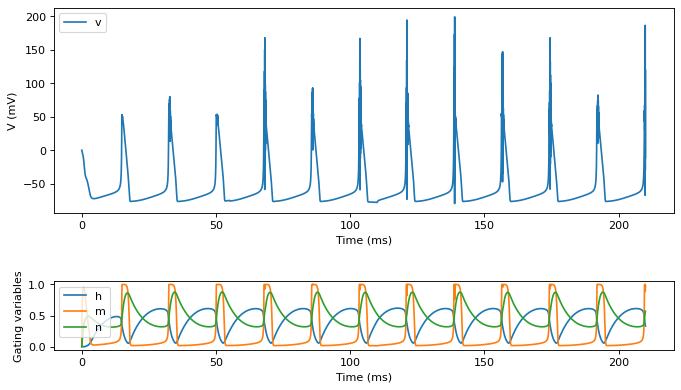

In [16]:
# Exercise 4
restore('setup')

gbar_Na   = 2*120. * mS / cm ** 2 # ('bar' means maximal conductance)

G.v = 0*mV
G.m = 0
G.n = 0
G.h = 0
run(50*ms)

G.I = 10*uA/cm**2
run(5*ms)

G.I = 0*uA/cm**2
run(50*ms)

G.I = -10*uA/cm**2
run(5*ms)

G.I = 0* uA/cm**2
run(100*ms)

# prepare a grid to plot graphs  (like function subplot in matlab)
grid = plt.GridSpec(5, 1, wspace=0.4, hspace=1)

# create figure
figure(figsize=(10, 10), dpi= 80, facecolor='w', edgecolor='k')

# in the first viewport plot membrane potential vs time
subplot(grid[:2, 0])
plot(M.t/ms, M.v[0]/mV, label='v')
xlabel('Time (ms)')
ylabel('V (mV)')
legend();

# plot the activation variables
subplot(grid[2, 0])
plot(M.t/ms, M.h[0], label='h')
plot(M.t/ms, M.m[0], label='m')
plot(M.t/ms, M.n[0], label='n')

xlabel('Time (ms)')
ylabel('Gating variables')
legend();

show()

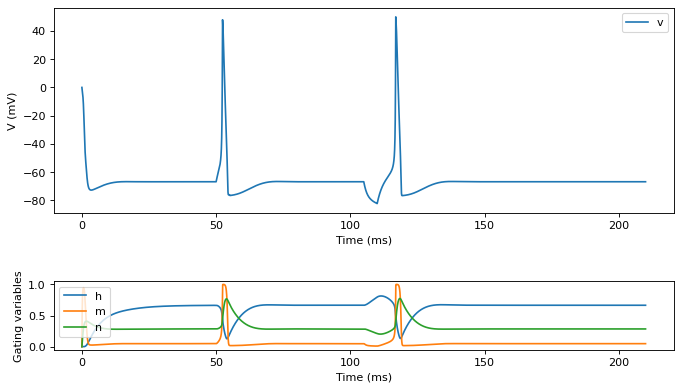

In [17]:
# Exercise 5
restore('setup')

gbar_Na   = 120. * mS / cm ** 2 # Change back to original
gbar_K    =  2*36. * mS / cm ** 2

G.v = 0*mV
G.m = 0
G.n = 0
G.h = 0
run(50*ms)

G.I = 10*uA/cm**2
run(5*ms)

G.I = 0*uA/cm**2
run(50*ms)

G.I = -10*uA/cm**2
run(5*ms)

G.I = 0* uA/cm**2
run(100*ms)

# prepare a grid to plot graphs  (like function subplot in matlab)
grid = plt.GridSpec(5, 1, wspace=0.4, hspace=1)

# create figure
figure(figsize=(10, 10), dpi= 80, facecolor='w', edgecolor='k')

# in the first viewport plot membrane potential vs time
subplot(grid[:2, 0])
plot(M.t/ms, M.v[0]/mV, label='v')
xlabel('Time (ms)')
ylabel('V (mV)')
legend();

# plot the activation variables
subplot(grid[2, 0])
plot(M.t/ms, M.h[0], label='h')
plot(M.t/ms, M.m[0], label='m')
plot(M.t/ms, M.n[0], label='n')

xlabel('Time (ms)')
ylabel('Gating variables')
legend();

show()

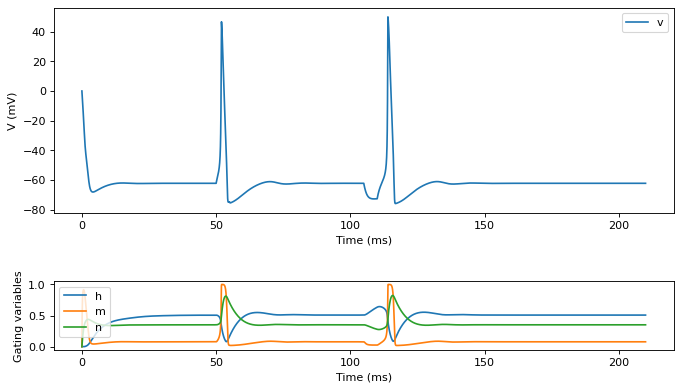

In [18]:
# Exercise 6
restore('setup')

g_leak =   2*300. * uS / cm ** 2
gbar_K    =  36. * mS / cm ** 2. #Change back to original

G.v = 0*mV
G.m = 0
G.n = 0
G.h = 0
run(50*ms)

G.I = 10*uA/cm**2
run(5*ms)

G.I = 0*uA/cm**2
run(50*ms)

G.I = -10*uA/cm**2
run(5*ms)

G.I = 0* uA/cm**2
run(100*ms)

# prepare a grid to plot graphs  (like function subplot in matlab)
grid = plt.GridSpec(5, 1, wspace=0.4, hspace=1)

# create figure
figure(figsize=(10, 10), dpi= 80, facecolor='w', edgecolor='k')

# in the first viewport plot membrane potential vs time
subplot(grid[:2, 0])
plot(M.t/ms, M.v[0]/mV, label='v')
xlabel('Time (ms)')
ylabel('V (mV)')
legend();

# plot the activation variables
subplot(grid[2, 0])
plot(M.t/ms, M.h[0], label='h')
plot(M.t/ms, M.m[0], label='m')
plot(M.t/ms, M.n[0], label='n')

xlabel('Time (ms)')
ylabel('Gating variables')
legend();

show()

## Challenges

### **Challenge 1.** Find two current injection protocols that produces exactly 3 spikes changing both the amplitude and duration of a single current square pulse.


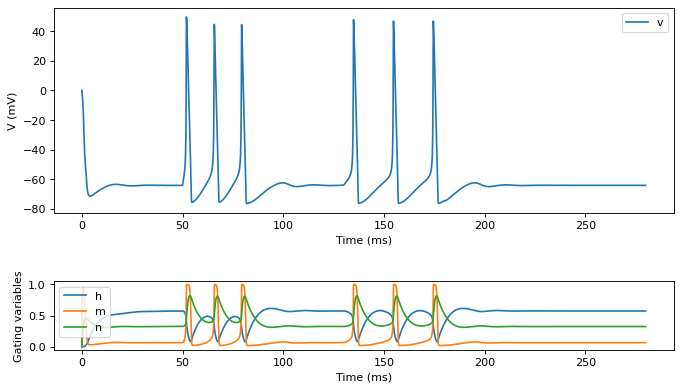

In [19]:
# Challenge 1
# start_scope() # initialize brian2 workspace
restore('setup')

g_leak =   300. * uS / cm ** 2  #Change back to original

# Membrane Capacitance
Cm = 1. * uF / cm ** 2

#Protocol 2
restore('setup')
G.v = 0*mV
G.m = 0
G.n = 0
G.h = 0
run(50*ms)

G.I = 10*uA/cm**2
run(30*ms)

G.I = 0*uA/cm**2
run(50*ms)

G.I = 2*uA/cm**2
run(50*ms)

G.I = 0* uA/cm**2
run(100*ms)

# prepare a grid to plot graphs  (like function subplot in matlab)
grid = plt.GridSpec(5, 1, wspace=0.4, hspace=1)

# create figure
figure(figsize=(10, 10), dpi= 80, facecolor='w', edgecolor='k')

# in the first viewport plot membrane potential vs time
subplot(grid[:2, 0])
plot(M.t/ms, M.v[0]/mV, label='v')
xlabel('Time (ms)')
ylabel('V (mV)')
legend();

# plot the activation variables
subplot(grid[2, 0])
plot(M.t/ms, M.h[0], label='h')
plot(M.t/ms, M.m[0], label='m')
plot(M.t/ms, M.n[0], label='n')
xlabel('Time (ms)')
ylabel('Gating variables')
legend();
show()

### **Challenge 2.** Can you tune the conductance values for the model to spike spontaneously (no injected current)?

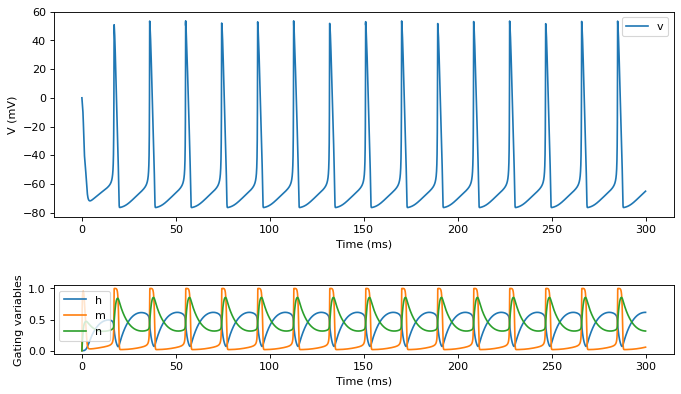

In [20]:
# Challenge 2:
restore('setup') # restore state of simulator

gbar_Na   = 1.5*120. * mS / cm ** 2

#Protocol 2
restore('setup')
G.v = 0*mV
G.m = 0
G.n = 0
G.h = 0
G.I = 0* uA/cm**2
run(300*ms)

# prepare a grid to plot graphs  (like function subplot in matlab)
grid = plt.GridSpec(5, 1, wspace=0.4, hspace=1)

# create figure
figure(figsize=(10, 10), dpi= 80, facecolor='w', edgecolor='k')

# in the first viewport plot membrane potential vs time
subplot(grid[:2, 0])
plot(M.t/ms, M.v[0]/mV, label='v')
xlabel('Time (ms)')
ylabel('V (mV)')
legend();

# plot the activation variables
subplot(grid[2, 0])
plot(M.t/ms, M.h[0], label='h')
plot(M.t/ms, M.m[0], label='m')
plot(M.t/ms, M.n[0], label='n')
xlabel('Time (ms)')
ylabel('Gating variables')
legend();
show()

# Final Challenge

For the model in Challenge 2, in a single panel:
- plot the trajectories of the m and n state variables against each other (that is m on the horizontal axis and n in the vertical axis). This type of plot is called a 'phase space', and is essential in the study of action potential generation mechanisms.
- plot the trajectories of the m and h state variables against each other.
(for both these plots use the horizontal coordinate (x) to plot m and the  vertical coordinate (y) to plot n and h).

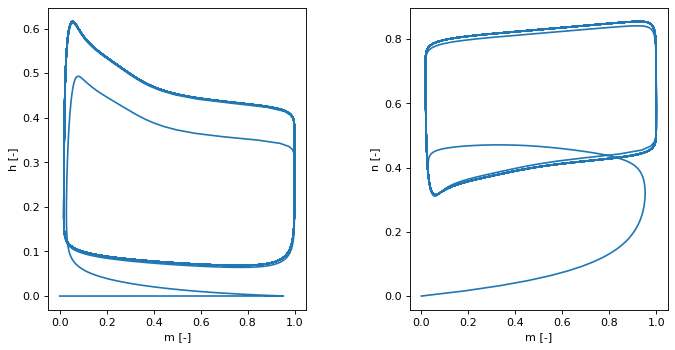

In [ ]:
# Final Challenge:

# prepare a grid to plot graphs  (like function subplot in matlab)
grid = plt.GridSpec(ncols=2, nrows=1, wspace=0.4, hspace=1)

# create figure
figure(figsize=(10, 5), dpi= 80, facecolor='w', edgecolor='k')

# plot m vs h
subplot(grid[0, 0])
plot(M.m[0], M.h[0])
xlabel('m [-]')
ylabel('h [-]')

# plot m vs n
subplot(grid[0, 1])
plot(M.m[0], M.n[0])
xlabel('m [-]')
ylabel('n [-]')
show()

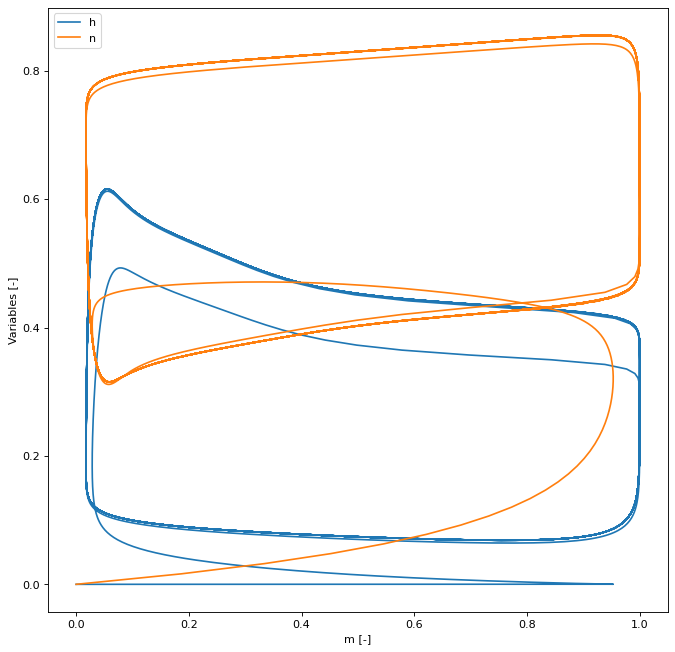

In [ ]:
# Other way of visualizing (both variables in same plot)

# create figure
figure(figsize=(10, 10), dpi= 80, facecolor='w', edgecolor='k')
# plot m vs h
plot(M.m[0], M.h[0], label='h')
# plot m vs n
plot(M.m[0], M.n[0], label='n')
xlabel('m [-]')
ylabel('Variables [-]')
legend();
show()

# Going Further

## Cable Equation and Compartmental Models

[![Saltatory-Conduction.gif](https://i.postimg.cc/0jv5hTFh/Saltatory-Conduction.gif)](https://postimg.cc/zbd1gcJk)

We have scratched the surface of action potential generation. Our primary goal in this course is to simplify the complexity of experiment into models that explain a wider phenomenology. But there are many interesting aspects that are left for you to discover, such as models with multiple compartments.

Here's my suggested list:
- Read about saltatory conductance in myelinated axons! https://en.wikipedia.org/wiki/Saltatory_conduction
- Watch Wulfram Gerstner's MOOC (chapter 3.b) :
  - https://www.edx.org/course/neuronal-dynamics
- Compute the propagation of an action potential in an axon in brian
- Play with the tutorial in pyramidal cells in opensourcebrain.org ("simulate electrophysiologically detailed cell models")
- Read and Run example of a multicompartmental cable with Brian:
  - multicompartmental axon: https://brian.readthedocs.io/en/stable/examples-misc_cable.html
  



# Further Online Resources

[Resting membrane potential](https://www.physiologyweb.com/lecture_notes/resting_membrane_potential/resting_membrane_potential.html)

[Action Potential](https://www.physiologyweb.com/lecture_notes/neuronal_action_potential/neuronal_action_potential.html)

[Bilipid Layer Permeability](https://www.physiologyweb.com/lecture_notes/biological_membranes/lipid_bilayer_permeability.html)

[Derivation of the Nernst Equation](https://www.physiologyweb.com/lecture_notes/resting_membrane_potential/derivation_of_the_nernst_equation.html)


#License

<a rel="license" href="http://creativecommons.org/licenses/by/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by/4.0/">Creative Commons Attribution 4.0 International License</a>.

Mario Negrello, Daphne Cornelise, Elias Santoro. Figure sources: Geometry of Bursting, Eugene Izhikevich (2007). Saltatory conductance gif by By Dr. Jana - http://docjana.com/saltatory-conduction/
